# Customer Churn Prediction - Data Understanding

## Objective
The goal of this notebook is to load the Telco Customer Churn dataset and understand its basic structure before doing any cleaning, visualization, or modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

## Dataset Shape

The dataset contains 7043 rows and 21 columns.
Each row represents one customer, and each column represents a customer attribute or the target variable.

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Columns and Data Types

The target variable is `Churn`, which indicates whether the customer left the company or not.

Most variables are categorical, while `tenure`, `MonthlyCharges`, and `TotalCharges` are numerical or should be treated as numerical.

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Missing Values

The first check shows whether each column contains missing values.  
At this stage, we are only identifying missing values, not fixing them yet.

In [9]:
df.duplicated().sum()

np.int64(0)

## Duplicate Rows

This check shows whether the dataset contains duplicate customer records.
If the result is 0, it means there are no fully duplicated rows in the dataset.

In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Target Variable Distribution

The target variable is `Churn`.

This check shows how many customers stayed and how many customers left the company.
It also helps us identify whether the dataset is balanced or imbalanced.

## Interpretation of Churn Distribution

The dataset contains two classes in the target variable: customers who churned and customers who did not churn.

The percentage of customers who did not churn is higher than the percentage of customers who churned.

This means the dataset is imbalanced, but not extremely imbalanced. Because of this, accuracy alone may not be enough to evaluate the model later. We will also need metrics such as precision, recall, F1-score, and ROC-AUC.

## Basic Statistical Summary

In this section, we check the basic statistical summary of the dataset.
This helps us understand the numerical variables before cleaning or visualization.

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
df.describe(include="object")

C:\Users\User\AppData\Local\Temp\ipykernel_13472\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [15]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [16]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

## TotalCharges Data Type Check

The `TotalCharges` column should represent a numerical value, but it may be stored as an object/text column.
Before modeling, this column will need to be converted to a numerical data type.

In [17]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## Hidden Blank Values in TotalCharges

Although `TotalCharges` looks numerical, Pandas reads it as a string column.

This usually happens because some rows contain blank spaces instead of real numerical values.

These blank spaces are not detected by `df.isnull().sum()` because they are stored as text, not as true missing values.

Later, during data cleaning, we will convert `TotalCharges` to a numerical column and handle the missing values created by that conversion.

In [18]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']


C:\Users\User\AppData\Local\Temp\ipykernel_13472\1214778948.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [19]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

Categorical columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


## Numerical and Categorical Features

The dataset contains both numerical and categorical variables.

Numerical variables include columns such as `tenure`, `MonthlyCharges`, and possibly `SeniorCitizen`.

Categorical variables include customer demographics, services, contract information, payment method, and the target variable `Churn`.

This distinction is important because numerical and categorical features will require different preprocessing steps before modeling.

In [20]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

## Number of Unique Values

This check shows how many unique values exist in each column.

Columns with only two unique values are usually binary categorical variables.

The `customerID` column should have a unique value for each customer, so it will probably not be useful for modeling.

## Initial Data Understanding Summary

At this stage, the dataset has been loaded and inspected.

Main observations:
- The dataset contains 7043 customers and 21 columns.
- The target variable is `Churn`.
- The dataset contains both numerical and categorical features.
- The `customerID` column is unique for each customer and will probably not be useful for modeling.
- The `TotalCharges` column looks numerical but is stored as text, so it will need to be converted during data cleaning.
- The target variable is imbalanced, with more customers who did not churn than customers who churned.

No cleaning or modeling has been done yet.

## Preparing TotalCharges for Cleaning

The `TotalCharges` column is stored as text, even though it represents a numerical value.
To prepare it for analysis and modeling, we need to convert it to a numeric column.

Before changing the original column, we will test the conversion and check how many missing values appear.

In [21]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [22]:
total_charges_numeric.isnull().sum()

np.int64(11)

In [23]:
df[total_charges_numeric.isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [24]:
df[total_charges_numeric.isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## Rows with Blank TotalCharges

After converting `TotalCharges` to numeric temporarily, some values became missing.

These rows correspond to customers with `tenure = 0`, meaning they are new customers and do not yet have accumulated total charges.

This explains why `TotalCharges` was stored as text instead of a numerical column.

## Cleaning TotalCharges

The `TotalCharges` column is converted from text to a numeric data type.

Blank values are converted into missing values using `errors="coerce"`.

In [25]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [26]:
df["TotalCharges"].dtype

dtype('float64')

In [27]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [28]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


## Missing Values After TotalCharges Conversion

After converting `TotalCharges` to numeric, some values became missing.

These missing values correspond to customers with `tenure = 0`, meaning they are new customers and have not accumulated total charges yet.

We will handle these missing values in the cleaning phase before modeling.

## Handling Missing TotalCharges Values

The missing values in `TotalCharges` correspond to customers with `tenure = 0`.

Since these customers are new and have not accumulated charges yet, replacing the missing `TotalCharges` values with 0 is a logical choice.

In [29]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [30]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [32]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Dataset After Initial Cleaning

After converting `TotalCharges` to numeric and replacing missing values with 0, the dataset no longer contains missing values in this column.

The `TotalCharges` column is now ready to be used as a numerical feature in future analysis and modeling.

## Basic Churn Analysis

In this section, we start exploring the target variable `Churn`.
The goal is to understand how many customers churned and how many stayed.

In [33]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

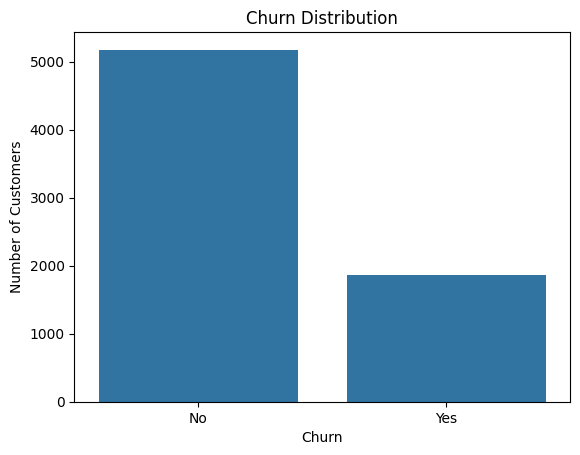

In [35]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Churn Distribution Visualization

The plot shows that the number of customers who did not churn is higher than the number of customers who churned.

This confirms that the target variable is imbalanced, meaning that accuracy alone may not be sufficient for model evaluation.

## Churn by Gender

In this section, we check whether churn differs between male and female customers.

In [37]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


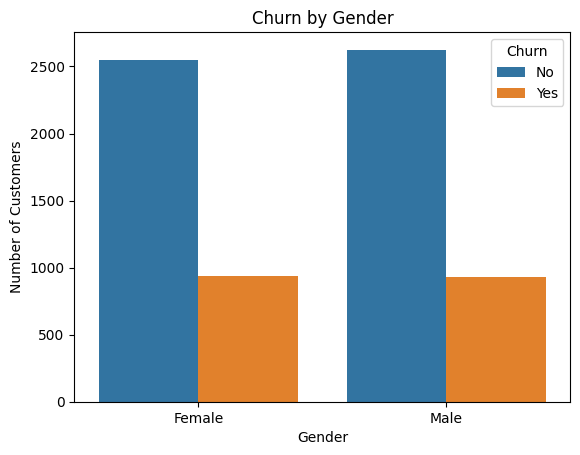

In [38]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## Interpretation: Churn by Gender

The churn percentage appears very similar between male and female customers.

This suggests that gender may not be a strong factor in predicting churn compared to other variables such as contract type, tenure, internet service, or payment method.

## Churn by Senior Citizen Status

In this section, we check whether senior citizens have a different churn rate compared to non-senior customers.

In [39]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


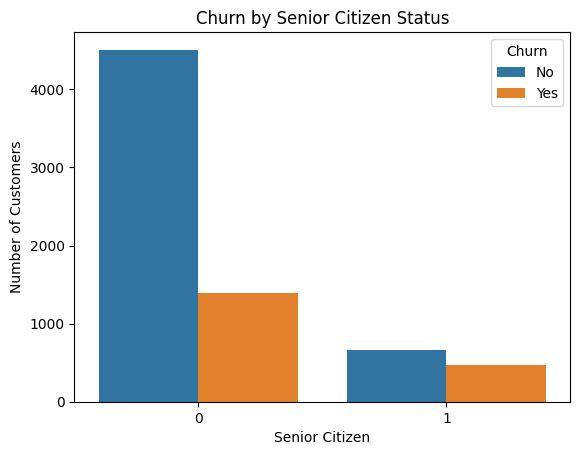

In [40]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

## Interpretation: Churn by Senior Citizen Status

The churn rate should be compared between senior citizens and non-senior customers.

If senior citizens show a higher churn percentage, this may indicate that age group is related to customer churn.
However, this should later be confirmed with modeling because EDA alone does not prove causation.

## Churn by Partner and Dependents

In this section, we check whether customers with a partner or dependents have different churn rates.

In [41]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index")* 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


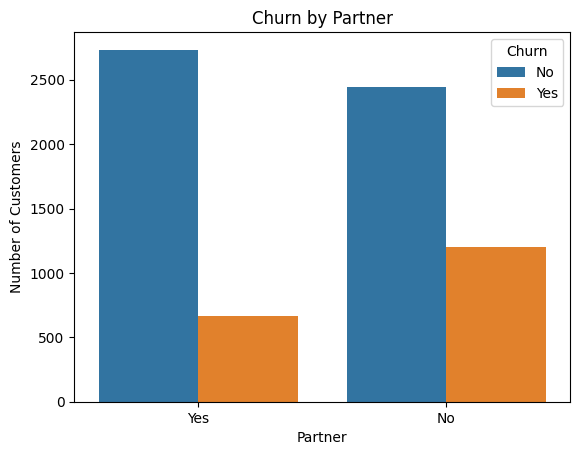

In [43]:
sns.countplot(data=df, x="Partner", hue="Churn")
plt.title("Churn by Partner")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

In [44]:
pd.crosstab(df["Dependents"],df["Churn"], normalize="index")*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


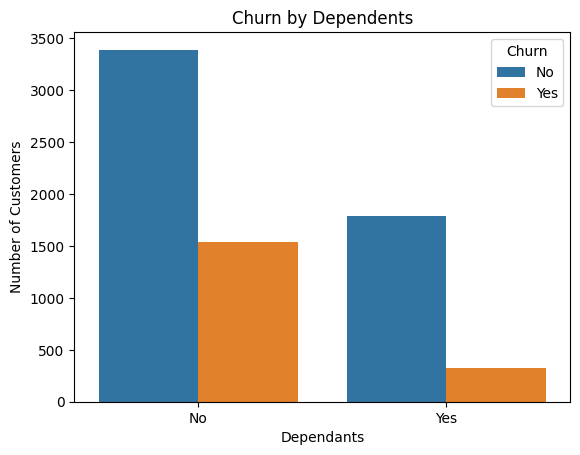

In [48]:
sns.countplot(data=df, x="Dependents", hue="Churn")
plt.title("Churn by Dependents")
plt.xlabel("Dependants")
plt.ylabel("Number of Customers")
plt.show()

## Interpretation: Partner and Dependents

Customers without a partner or without dependents may show a higher churn rate.

This could suggest that customers with stronger household or family-related service needs may be more stable, but this should be confirmed later using machine learning models.

## Churn by Contract Type

In this section, we analyze whether the type of customer contract is related to churn.

In [49]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


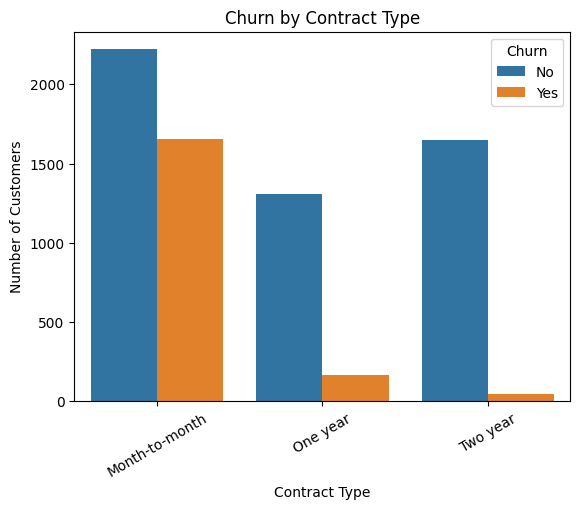

In [50]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

## Interpretation: Churn by Contract Type

Contract type appears to be strongly related to churn.

Customers with month-to-month contracts usually show a much higher churn rate than customers with one-year or two-year contracts.

This suggests that customers with longer contracts may be more stable and less likely to leave the company.

## Churn by Payment Method

In this section, we analyze whether the payment method is related to customer churn.

In [52]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


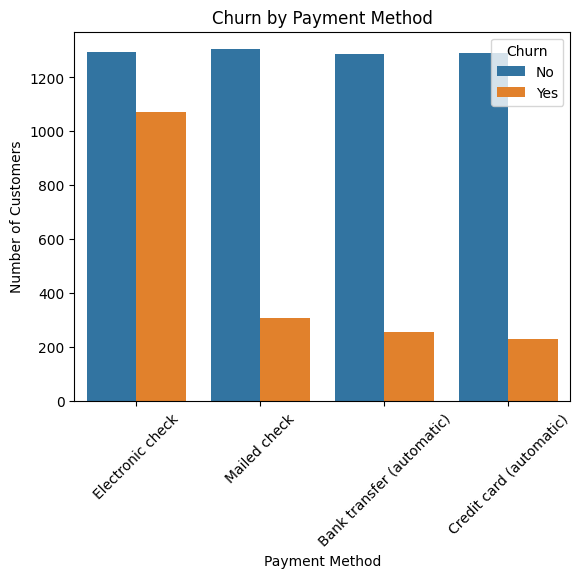

In [53]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## Interpretation: Churn by Payment Method

Churn rate should be compared across the different payment methods.

If one payment method shows a much higher churn percentage, this may indicate that payment behavior is associated with churn.

This relationship should later be confirmed using machine learning models.

## Churn by Internet Service

In this section, we analyze whether the type of internet service is related to customer churn.

In [54]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


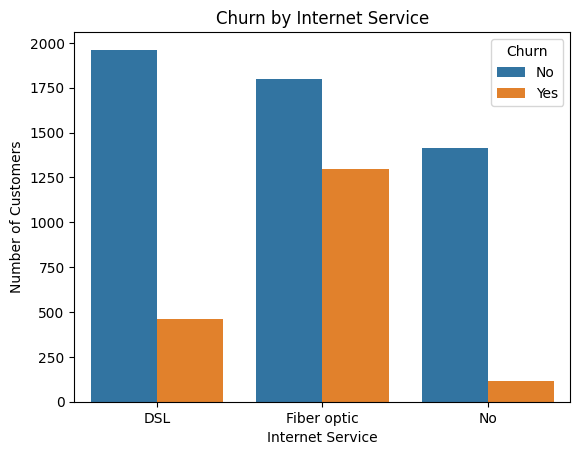

In [55]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

## Interpretation: Churn by Internet Service

Churn rate should be compared across DSL, Fiber optic, and customers with no internet service.

If one internet service type has a higher churn percentage, this may suggest that service type or customer experience is associated with churn.

## Churn by Online Security and Tech Support

In this section, we analyze whether having online security or tech support is related to churn.

In [ ]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100


Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


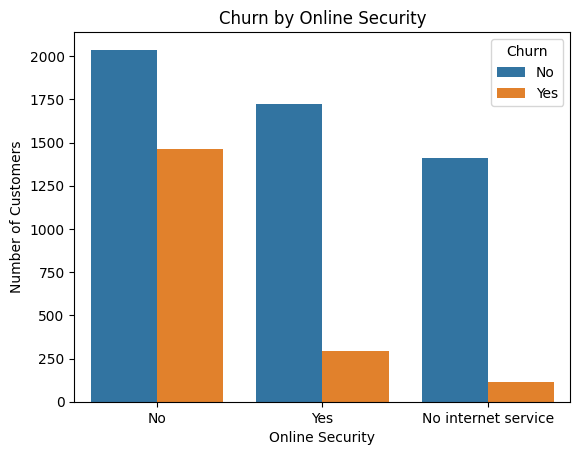

In [57]:
sns.countplot(data=df, x="OnlineSecurity", hue="Churn")
plt.title("Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

In [58]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


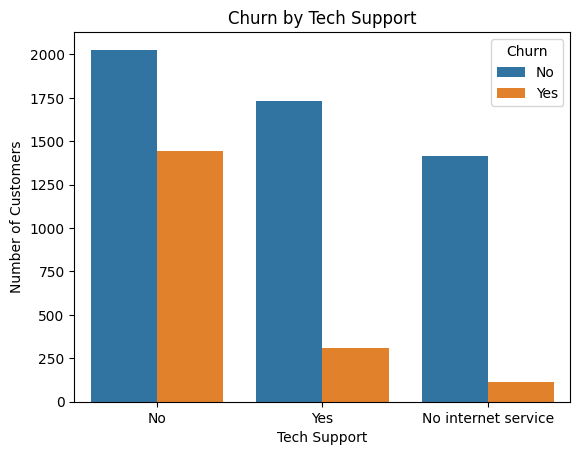

In [59]:
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

## Interpretation: Online Security and Tech Support

Customers without online security or tech support may show a higher churn rate.

This suggests that customers who receive additional support or protection services may be more likely to stay with the company.

## Churn by Tenure

In this section, we analyze whether customer tenure is related to churn.

Tenure represents how long a customer has stayed with the company.

In [60]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


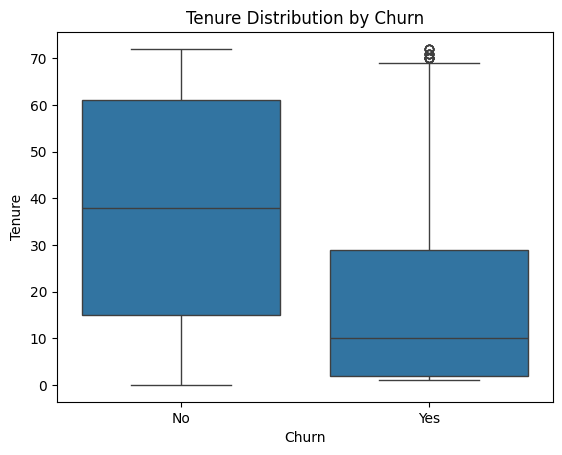

In [61]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

## Interpretation: Tenure and Churn

Customers who churn usually have lower tenure compared to customers who stay.

This suggests that newer customers may be more likely to leave, while long-term customers are more stable.

## Churn by Monthly Charges

In this section, we analyze whether monthly charges are related to customer churn.

In [62]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


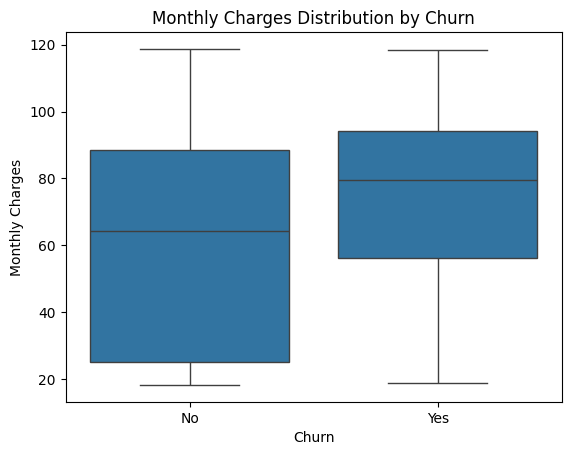

In [63]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## Interpretation: Monthly Charges and Churn

Customers who churn may have higher monthly charges compared to customers who stay.

This suggests that pricing or perceived value may be associated with churn.
However, this relationship should later be confirmed using modeling.

## Churn by Total Charges

In this section, we analyze whether total charges are related to customer churn.

In [64]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


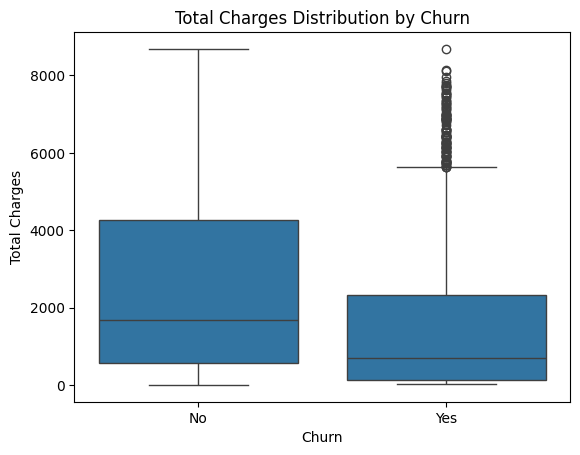

In [65]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

## Interpretation: Total Charges and Churn

Total charges should be interpreted together with tenure.

Customers with low total charges may be newer customers, while customers with high total charges usually have stayed longer.

Because tenure and total charges are related, we should be careful when interpreting this variable alone.

## Tenure vs Monthly Charges by Churn

In this section, we analyze the relationship between tenure, monthly charges, and churn.

This helps us see whether customers with short tenure and high monthly charges are more likely to churn.

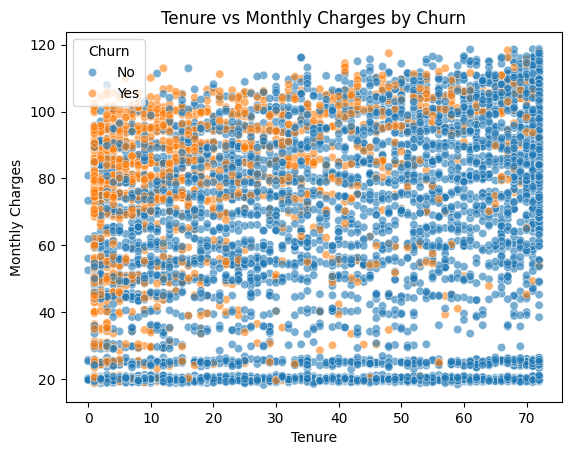

In [66]:
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.6)
plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

## Interpretation: Tenure vs Monthly Charges

This plot helps us observe whether churned customers are concentrated in specific areas.

If many churned customers appear at low tenure and high monthly charges, this may suggest that newer customers with expensive plans are at higher risk of churn.

## Correlation Between Numerical Features

In this section, we check the correlation between numerical variables.

This helps us understand whether some numerical features are related to each other.

In [67]:
numeric_df = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]]

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


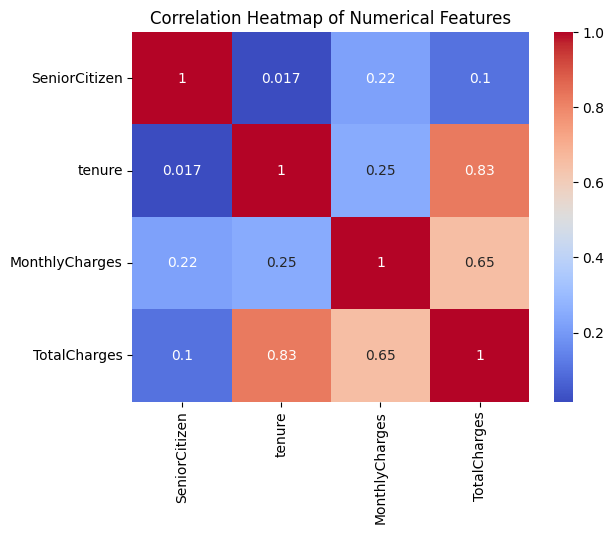

In [68]:
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Interpretation: Numerical Correlations

`tenure` and `TotalCharges` are expected to have a strong positive correlation, because customers who stay longer usually accumulate higher total charges.

This means we should be careful when interpreting these two variables together.

## Churn Rate Summary for Important Categorical Features

In this section, we summarize churn rates for several important categorical variables.

This makes it easier to compare which categories are associated with higher churn.

In [69]:
important_categorical_features = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport"
]

for col in important_categorical_features:
    print(f"\nChurn rate by {col}:")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


Churn rate by Contract:


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



Churn rate by PaymentMethod:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700



Churn rate by InternetService:


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980



Churn rate by OnlineSecurity:


Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194



Churn rate by TechSupport:


Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


## EDA Summary: Factors Associated with Churn

Based on the exploratory analysis, several variables appear to be associated with customer churn.

Main observations:
- `Contract` appears strongly related to churn. Month-to-month customers show a higher churn rate.
- `tenure` appears important. Customers with lower tenure seem more likely to churn.
- `MonthlyCharges` may be related to churn. Customers who churn may have higher monthly charges.
- `PaymentMethod` may be associated with churn, especially if one payment type shows a higher churn percentage.
- `InternetService`, `OnlineSecurity`, and `TechSupport` also appear related to churn.
- `gender` does not appear to show a strong difference in churn behavior.

These observations are based only on exploratory analysis. They do not prove causation. Later, machine learning models will help determine which variables are most useful for prediction.